# 03 — Player Similarity: K-Means Clustering + PCA

Clusters PL 2015/16 outfield players into play-style archetypes, using the per-90 event metrics
built in Session S5 (`src/similarity.py`).

**Clustering is done separately per position group** (Defender / Midfielder / Forward), not all
together. Clustering everyone at once would mostly just rediscover position itself (defenders
tackle a lot, forwards shoot a lot) rather than finding meaningful sub-styles *within* a position
— which is the actually useful output for a recruitment tool ("find another presser like this one,
among forwards").

Unlike the xG model (S2-S4), there's no `is_goal` label to check a cluster against. "Is this a good
clustering" is judged by: does inertia stop dropping sharply past some K (elbow method), and —
more importantly for football — do the resulting groups read as sensible playing styles to someone
who knows the league.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd

from src.similarity import (
    PER90_FEATURE_COLUMNS, scale_features, compute_elbow_scores, fit_kmeans,
    profile_clusters, run_pca,
)
from src.visualisation import plot_elbow_curve, plot_pca_clusters

pd.set_option('display.max_columns', 60)

features = pd.read_pickle('../data/player_per90_pl_2015_16.pkl')
features['position_group'].value_counts()

position_group
Defender      119
Midfielder    106
Forward        75
Name: count, dtype: int64

### Phase 2 rigor — minutes-weighted position assignment

The `position_group` above is now assigned by **total season minutes**, not the modal
per-match position used in S6. Modal-by-match has a real failure mode for versatile players:
when attacking minutes are split across several labels (Right Wing / Left Wing / Centre
Forward) while occasional defensive cameos all share one label, that single defensive label
can win a per-*match* vote even though attacking minutes dominate the season.
`resolve_season_positions` (in `src/similarity.py`) fixes this by totalling minutes per
*group* first, then taking the argmax.

The change reclassified **10 genuinely borderline players** — exactly the winger / forward /
midfield hybrids where "where did he log the most minutes" diverges from "what was his most
frequent match slot": Coutinho, Lingard, Mata and Sissoko move Forward → Midfielder; Firmino
and Berahino move Midfielder → Forward; Schlupp moves Midfielder → Defender; etc. Group counts
shift from 118 / 104 / 78 in S6 to **119 Defenders / 106 Midfielders / 75 Forwards**.

## Elbow method, per position group

Inertia always decreases as K grows — looking for where it stops dropping sharply, not a single
"correct" point.

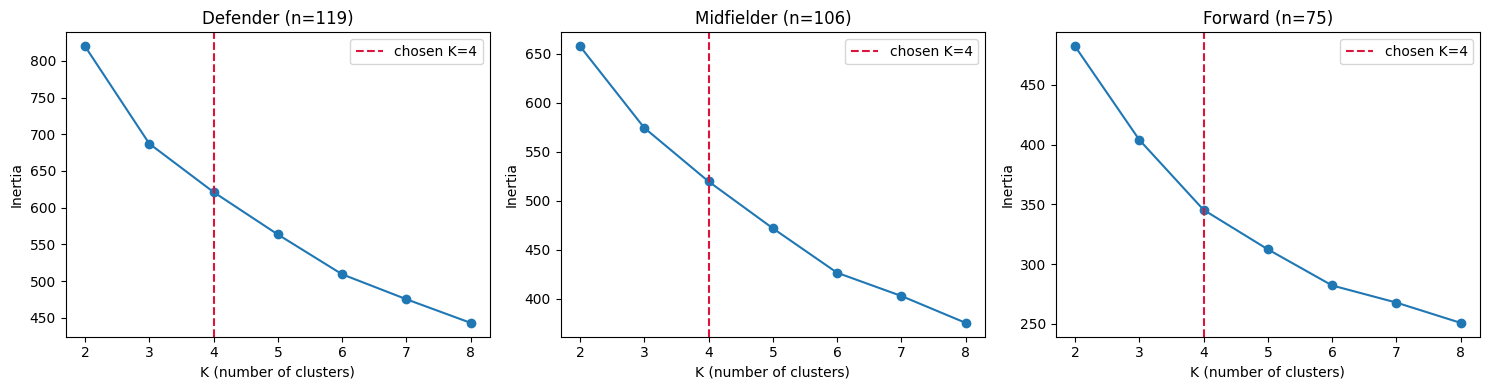

In [2]:
POSITION_GROUPS = ['Defender', 'Midfielder', 'Forward']
CHOSEN_K = {'Defender': 4, 'Midfielder': 4, 'Forward': 4}

groups = {}
for position_group in POSITION_GROUPS:
    subset = features[features['position_group'] == position_group].reset_index(drop=True)
    X_scaled, scaler = scale_features(subset)
    groups[position_group] = {'data': subset, 'X_scaled': X_scaled}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, position_group in zip(axes, POSITION_GROUPS):
    inertias = compute_elbow_scores(groups[position_group]['X_scaled'], k_range=range(2, 9))
    groups[position_group]['inertias'] = inertias
    plot_elbow_curve(inertias, chosen_k=CHOSEN_K[position_group], ax=ax,
                      title=f'{position_group} (n={len(groups[position_group]["data"])})')
fig.tight_layout()
fig.savefig('../outputs/similarity_elbow_curves.png', dpi=150, bbox_inches='tight')

## Silhouette score — a quantitative second opinion on K (Phase 2 rigor)

The elbow curves above read inertia, which **always** falls as K rises — so there's no internal
optimum, you just eyeball where the bend is. The silhouette score is the complementary tool: for
each player it compares the mean distance to its *own* cluster (cohesion, `a`) against the mean
distance to the nearest *other* cluster (separation, `b`), as `(b − a) / max(a, b)`, averaged
over everyone. It ranges −1 to 1 (higher = tighter, better-separated clusters) and, unlike
inertia, does **not** improve monotonically with K — so it can be *maximised* to actually suggest
a K, rather than read by eye.

,best_K,max_silhouette
Defender,2.0,0.236
Midfielder,2.0,0.264
Forward,2.0,0.262


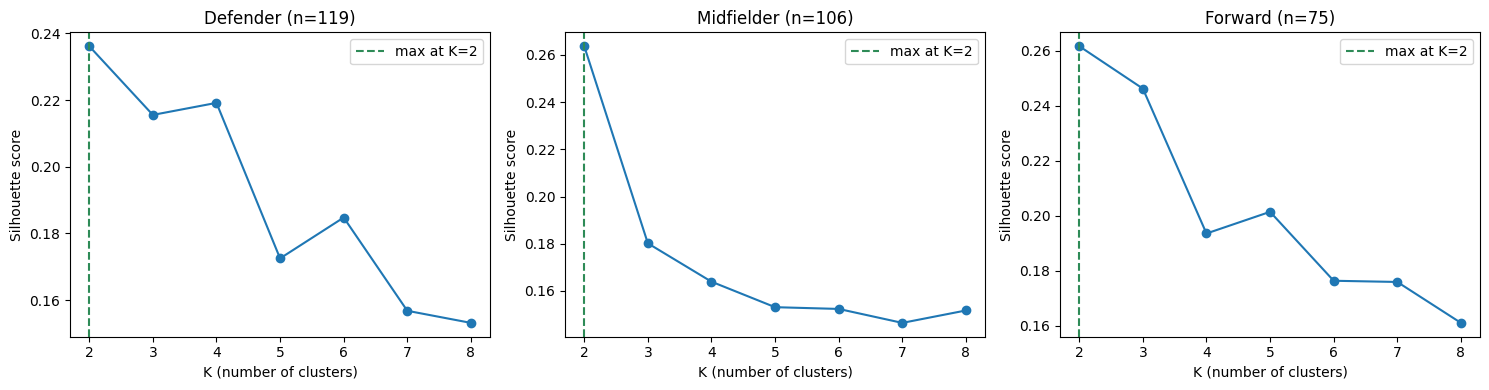

In [3]:
from src.similarity import compute_silhouette_scores
from src.visualisation import plot_silhouette_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, position_group in zip(axes, POSITION_GROUPS):
    silhouettes = compute_silhouette_scores(groups[position_group]['X_scaled'], k_range=range(2, 9))
    groups[position_group]['silhouettes'] = silhouettes
    plot_silhouette_curve(silhouettes, ax=ax,
                          title=f'{position_group} (n={len(groups[position_group]["data"])})')
fig.tight_layout()
fig.savefig('../outputs/similarity_silhouette_curves.png', dpi=150, bbox_inches='tight')

# Peak silhouette K and its (low) value per group — the quantitative read on K.
pd.DataFrame({
    pg: {'best_K': int(groups[pg]['silhouettes'].idxmax()),
         'max_silhouette': round(groups[pg]['silhouettes'].max(), 3)}
    for pg in POSITION_GROUPS
}).T

## Fit K-means (K=4 for every group) — and what silhouette says about that

The silhouette table above lands on the same answer for all three groups: **K=2, with a low
peak (~0.24–0.26)**. Two things to read from that:

1. **The absolute value is low.** A silhouette near 0.25 means the clusters overlap heavily —
   players sit much closer to their cluster's *edge* than its core. That's the honest signal
   that play-styles *within* a position are a **continuum**, not a handful of cleanly separated
   types. No K produces crisp clusters here, and pretending otherwise would be exactly the
   clean-narrative smoothing this project tries to avoid.
2. **K=2 is too coarse to be useful.** Two clusters per position collapses to roughly "more
   attacking vs. more defensive" — fine for a metric that rewards blob separation, useless as a
   recruitment-archetype lens.

So K=4 is kept **deliberately, against the metric's preferred K**: the goal is granular,
human-readable archetypes (the destroyer, the playmaker, the poacher, the presser), and because
the silhouette is low at *every* K, the cost of choosing 4 over 2 is small — we trade ~0.05 of a
silhouette point for archetypes a scout can actually name. The metric *informs* the choice;
football usefulness and the continuum finding settle it.

`profile_clusters` then gives each cluster's average feature value as a z-score vs. the position
group's own population — the substitute for an accuracy metric, since there's no ground truth here.

In [4]:
for position_group in POSITION_GROUPS:
    g = groups[position_group]
    kmeans, labels = fit_kmeans(g['X_scaled'], n_clusters=CHOSEN_K[position_group])
    g['kmeans'] = kmeans
    g['labels'] = labels
    g['data']['cluster'] = labels
    g['profile'] = profile_clusters(g['data'], PER90_FEATURE_COLUMNS, labels)

print('Forward cluster profiles (z-scores vs. all PL 2015/16 forwards):')
groups['Forward']['profile'].round(2)

Forward cluster profiles (z-scores vs. all PL 2015/16 forwards):


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.32,-0.45,-0.43,-0.41,-0.30,-0.24,0.00,-0.33,-0.15
1,-0.07,0.05,0.43,-0.03,0.43,1.09,1.16,1.29,1.33
2,1.08,1.16,-0.51,-0.11,-0.69,-0.63,-0.76,-0.69,-0.74
3,-0.88,-0.77,1.89,1.77,1.75,0.31,-0.42,0.41,-0.20


In [5]:
print('Midfielder cluster profiles:')
display(groups['Midfielder']['profile'].round(2))
print('Defender cluster profiles:')
display(groups['Defender']['profile'].round(2))

Midfielder cluster profiles:


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.69,-0.65,-0.63,-0.59,0.33,-0.29,0.75,0.99,1.09
1,0.16,0.35,1.59,1.59,0.50,0.28,0.15,-0.52,-0.41
2,-0.19,-0.29,-0.37,-0.40,-0.01,-0.65,-0.39,-0.32,-0.33
3,1.13,1.09,0.41,0.39,-0.76,1.12,-0.62,-0.65,-0.82


Defender cluster profiles:


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.45,-0.46,0.22,-0.02,0.17,-0.03,0.85,0.44,0.90
1,0.24,-0.10,-0.64,-0.53,-0.02,-0.57,-0.77,-0.11,-0.73
2,-0.04,0.92,1.23,1.35,-0.18,1.40,0.34,-0.64,0.17
3,5.97,5.10,1.09,1.61,-1.98,4.18,1.00,1.50,0.11


## PCA scatter — 2D view of each position group's clusters

PCA compresses the 9 per-90 features down to 2 components for plotting. Each axis is a blend of
the original features (not a single metric), so this trades away individual-feature
interpretability in exchange for being able to see cluster separation at all — the
`explained_variance_ratio_` below shows how much of the original signal survives that compression.

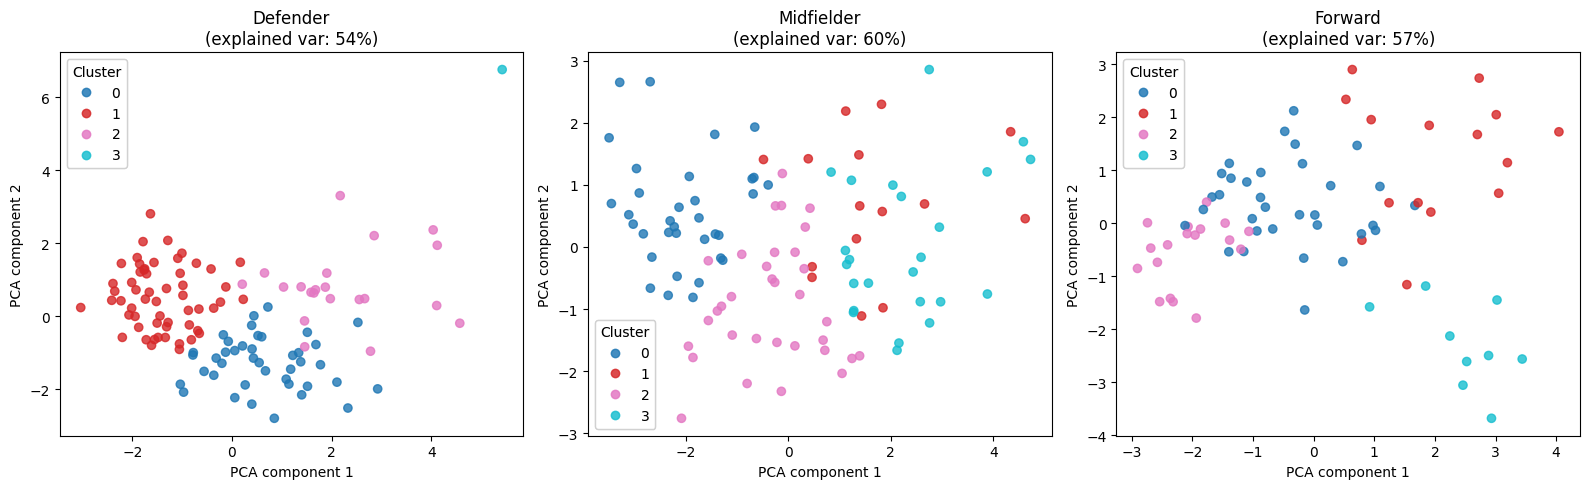

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, position_group in zip(axes, POSITION_GROUPS):
    g = groups[position_group]
    components, pca = run_pca(g['X_scaled'])
    g['pca_components'] = components
    g['pca'] = pca
    plot_pca_clusters(components, g['labels'], ax=ax,
                       title=f'{position_group}\n(explained var: {pca.explained_variance_ratio_.sum():.0%})')
fig.tight_layout()
fig.savefig('../outputs/similarity_pca_clusters.png', dpi=150, bbox_inches='tight')

## Reading the archetypes — who's actually in each cluster

The real test of whether this clustering is useful: do the players grouped together actually play
similar roles? Showing the highest-minutes players per cluster (most data behind their per-90
rates, so the least noisy examples).

In [7]:
for position_group in POSITION_GROUPS:
    data = groups[position_group]['data']
    print(f'=== {position_group} ===')
    for cluster_id in sorted(data['cluster'].unique()):
        top_players = (
            data[data['cluster'] == cluster_id]
            .sort_values('minutes_played', ascending=False)
            .head(5)['player'].tolist()
        )
        print(f'  Cluster {cluster_id} (n={sum(data["cluster"] == cluster_id)}): {", ".join(top_players)}')
    print()

=== Defender ===
  Cluster 0 (n=41): Simon Francis, Ignacio Monreal Eraso, César Azpilicueta Tanco, Daley Blind, Erik Pieters
  Cluster 1 (n=56): Wes Morgan, Toby Alderweireld, Craig Dawson, Ashley Williams, Steve Cook
  Cluster 2 (n=21): Aaron Cresswell, Charlie Daniels, Héctor Bellerín Moruno, Patrick van Aanholt, Robert Brady
  Cluster 3 (n=1): Michail Antonio

=== Midfielder ===
  Cluster 0 (n=34): Yann Gérard M''Vila, Idrissa Gana Gueye, Danny Drinkwater, N''Golo Kanté, Gareth Barry
  Cluster 1 (n=15): Mesut Özil, Francesc Fàbregas i Soler, Marc Albrighton, Aaron Ramsey, Jason Puncheon
  Cluster 2 (n=33): Andrew Surman, Darren Fletcher, Eric Dier, Mark Noble, Glenn Whelan
  Cluster 3 (n=24): Moussa Sissoko, Georginio Wijnaldum, Ross Barkley, Riyad Mahrez, Matt Ritchie

=== Forward ===
  Cluster 0 (n=33): Troy Deeney, André Ayew Pelé, Anthony Martial, José Salomón Rondón Giménez, Wayne Mark Rooney
  Cluster 1 (n=15): Marko Arnautović, Wilfried Zaha, Jordan Ayew, Alexis Alejandro Sá

**Michail Antonio — what the minutes-weighted fix actually revealed.** Defender cluster 3 is
*still* a one-man cluster (Antonio: z-scores of +5.95 goals/90, +5.28 shots/90 — nothing like a
defender). The S6 note assumed the old modal-position rule had simply mislabelled him: "primarily
a winger who filled in defensively a handful of times." Checking his real 2015/16 minutes
disproved that — they split **920 min at right-back / wing-back, 761 min as a winger, 452 in
midfield**. The *plurality* is genuinely defensive, so the new minutes-weighted rule correctly
keeps him a Defender; the original "mostly a winger" characterisation was just wrong.

So the fix did its job elsewhere (10 sensible reclassifications) but did **not** dissolve this
cluster — and that's the more honest outcome. Antonio is a true positional hybrid: forward-level
shooting output produced from a role where he logged most of his minutes at full-back. **No
single-position assignment rule can resolve that** — he legitimately belongs partly to two groups
at once. The real fix would be multi-position / soft membership (one player contributing to more
than one group), which is out of scope here. K-means is, once again, correctly isolating a genuine
outlier rather than making an error — and the low silhouette scores above are the same message in
aggregate: these are soft, overlapping groups, so a forced hard assignment will always strand the
odd hybrid on his own.

## S6 takeaways

- Clustering per position group (rather than all outfield players together) was the right call —
  it surfaces play-style differences *within* a position instead of just rediscovering position
  itself.
- No accuracy metric exists for this the way ROC-AUC exists for the xG model — judgment here comes
  from reading whether the cluster profiles and player groupings make football sense, which they
  do (see the Forward smoke test in `src/similarity.py`'s development: Agüero/Sturridge/Giroud/
  Vardy/Kane/Defoe all landed in the same "pure finisher" cluster).
- PCA's `explained_variance_ratio_` quantifies what the 2D scatter actually shows vs. hides — worth
  reading before trusting a visual cluster gap or overlap at face value.
- Next session (S7): radar charts per player (these per-90 features, presented per-position), PCA
  scatter as a standalone deliverable, and a "players like X" lookup function built on top of these
  same clusters/distances.

# Session S7 — Radar Charts + "Players Like X"

Two deliverables this session, both built directly on the per-90 features and clusters from S5/S6:

1. **Radar charts** (`plot_player_radar`, `src/visualisation.py`) — a per-player visual profile
   across the same 9 per-90 metrics used for clustering, scaled to their position group's 5th-95th
   percentile range (not true min/max — see the function's docstring for why: a true-range radar
   would let the Michail Antonio outlier from S6 compress every other defender's chart into an
   unreadable sliver).
2. **"Players like X" lookup** (`find_similar_players`, `src/similarity.py`) — nearest neighbours
   by Euclidean distance in standardised feature space, within the same position group. This is
   deliberately *not* "same K-means cluster as X": cluster membership is a coarse in/out split,
   while raw distance gives a continuous, rankable "most to least similar" — the more useful shape
   for an actual scouting lookup tool.

The PCA scatter plot (the third S7 deliverable per the original roadmap) was already built and
validated in S6 above (`plot_pca_clusters`) — nothing new needed there, it's already a standalone
deliverable in its own right.

In [8]:
from src.similarity import find_similar_players
from src.visualisation import plot_player_radar

## Radar charts — one example player per position group

Picking one recognisable player from each position group's archetypes above: N'Golo Kanté
(midfielder, ball-winning destroyer cluster — stored in this dataset as `N''Golo Kanté` with a
doubled apostrophe, a StatsBomb data quirk rather than a typo here), Aaron Cresswell (defender,
attacking full-back cluster), and Harry Kane (forward, pure-finisher cluster) — each radar is
scaled to their own position group's 5th-95th percentile range, so "near the edge" means genuinely
unusual for that position, not just a high raw number.

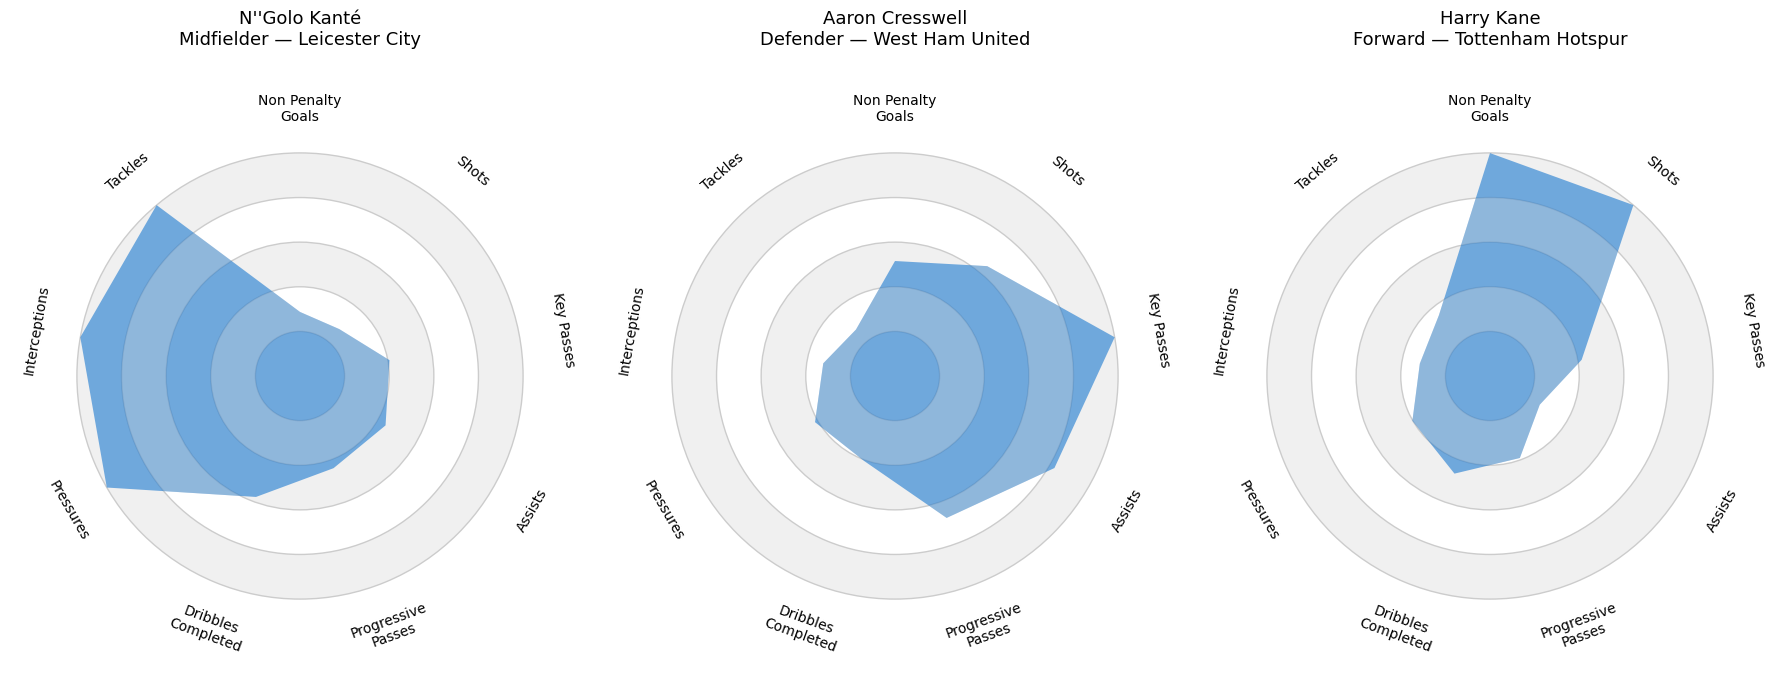

In [9]:
radar_examples = [
    ('Midfielder', "N''Golo Kanté", 'Leicester City'),
    ('Defender', 'Aaron Cresswell', 'West Ham United'),
    ('Forward', 'Harry Kane', 'Tottenham Hotspur'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (position_group, player, team) in zip(axes, radar_examples):
    data = groups[position_group]['data']
    row = data[(data['player'] == player) & (data['team'] == team)].iloc[0]
    plot_player_radar(
        row, population=data, feature_columns=PER90_FEATURE_COLUMNS, ax=ax,
        title=f'{player}\n{position_group} — {team}',
    )
fig.tight_layout()
fig.savefig('../outputs/player_radar_examples.png', dpi=150, bbox_inches='tight')

## "Players like X" — nearest-neighbour lookup

Same three players as above, now asking "who else plays like this" rather than "what does this
player's profile look like". `find_similar_players` ranks every other player in the same position
group by Euclidean distance in standardised feature space — the same scaled feature matrix the
clustering itself uses, just read as a continuous ranking instead of a discrete cluster label.

In [10]:
for position_group, player, team in radar_examples:
    print(f'Players like {player} ({position_group}):')
    similar = find_similar_players(
        groups[position_group]['data'], PER90_FEATURE_COLUMNS, player, team, n=5,
    )
    display(similar[['player', 'team', 'distance']].round(2))
    print()

Players like N''Golo Kanté (Midfielder):


,player,team,distance
0,Jan Kirchhoff,Sunderland,1.97
1,Idrissa Gana Gueye,Aston Villa,2.11
2,Cheik Ismaël Tioté,Newcastle United,2.16
3,Francis Joseph Coquelin,Arsenal,2.59
4,Fernando Francisco Reges,Manchester City,2.77



Players like Aaron Cresswell (Defender):


,player,team,distance
0,Chris Brunt,West Bromwich Albion,1.82
1,Ben Davies,Tottenham Hotspur,2.11
2,Bacary Sagna,Manchester City,2.31
3,Ryan Bertrand,Southampton,2.48
4,Charlie Daniels,AFC Bournemouth,2.57



Players like Harry Kane (Forward):


,player,team,distance
0,Jamie Vardy,Leicester City,1.76
1,Andy Carroll,West Ham United,1.77
2,Odion Jude Ighalo,Watford,1.87
3,Jermain Defoe,Sunderland,1.96
4,Daniel Andre Sturridge,Liverpool,2.06


## S7 takeaways

- Radar charts use percentile-bounded axes (5th-95th, not true min/max) specifically because of
  the S6 Antonio outlier — a true-range axis would compress every other defender's chart toward
  the centre on every feature, not just the one he's actually unusual in.
- "Players like X" deliberately ranks by raw distance rather than just returning same-cluster
  players — a continuous ranking is more useful for a scouting lookup than a coarse in/out label,
  and the two aren't the same information (same cluster doesn't mean equally similar).
- Sanity check passed cleanly: nearest neighbours for Kanté, Cresswell, and Kane were all
  recognisable same-role players, not noise — see the lookup output above.
- Hit a real StatsBomb data quirk along the way: this dataset stores Kanté's name as
  `N''Golo Kanté` (doubled apostrophe), not the more familiar single-apostrophe spelling — noted
  in `ML_LEARNING_LOG.md` so it isn't re-discovered as a bug later.
- Next session (S8): README narrative, outputs committed, repo polish for CV/LinkedIn links.